# Etapa 2 — EDA espacial y temporal

---
> Conjunto de datos obtenido del Servicio Sismológico Nacional, adscrito al Instituto de Geofísica de la Universidad Nacional Autónoma de México

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
from folium.plugins import HeatMap
from pathlib import Path
from IPython.display import display, HTML

In [2]:
df = pd.read_parquet('seismos_clean.parquet')

# Momento sísmico relativo: M0 ∝ 10^(1.5·M)
# Pondera correctamente la energía: un M7 vale ~1000 veces más que un M5
df['momento_sismico'] = 10 ** (1.5 * df['Magnitud'])

# Subset limpio: sismos sobre la Mc de su época
df_mc = df[df['sobre_Mc']].copy()

print(f'Dataset completo: {len(df):>8,}')
print(f'Sobre Mc (análisis limpio): {len(df_mc):>8,}')
print(f'Rango temporal: {df["datetime_utc"].min().date()} → {df["datetime_utc"].max().date()}')
df_mc.head(3)

Dataset completo:  368,895
Sobre Mc (análisis limpio):  232,270
Rango temporal: 1974-01-04 → 2026-06-20


,Magnitud,Latitud,Longitud,Profundidad,Referencia de localizacion,datetime_utc,hora_local,estado,year,Mc_epoca,sobre_Mc,momento_sismico
0,4.3,19.54,-108.04,33.0,"317 km al SUROESTE de PUERTO VALLARTA, JAL",1974-01-04 01:33:19+00:00,19,JAL,1974,4.2,True,2.818383e+06
1,4.8,14.49,-93.80,51.0,"144 km al SUROESTE de MAPASTEPEC, CHIS",1974-01-04 17:54:57+00:00,11,CHIS,1974,4.2,True,1.584893e+07
2,4.3,13.96,-92.51,33.0,"88 km al SUROESTE de CD HIDALGO, CHIS",1974-01-05 12:38:25+00:00,6,CHIS,1974,4.2,True,2.818383e+06


Para facilitar el análisis de clasificación a implementar posteriormente, haremos uso de Binning en la profundidad en tres categorías:

1. Superficial: Para profundidades menores a 70.
2. Intermedio: Profundidades menores a 300
3. Profundo: Mayores a 300

In [3]:
def clasificar_profundidad(p):
    if pd.isna(p):        
        return 'Desconocida'
    elif p < 70:          
        return 'Superficial'
    elif p <= 300:        
        return 'Intermedio'
    else:                 
        return 'Profundo'

df_mc['categoria_prof'] = df_mc['Profundidad'].apply(clasificar_profundidad)

print('Distribución por categoría de profundidad:')
print(df_mc['categoria_prof'].value_counts())

Distribución por categoría de profundidad:
categoria_prof
Superficial    190677
Intermedio      41591
Profundo            2
Name: count, dtype: int64


Analicemos a través de un heatmap la distribución de sismos utilizando el movimiento sísmico relativo dado por:

$$M_0 \propto 10^{1.5\cdot M_w}$$

Esta ecuación proviene de la definición estándar de la escala de Magnitud de Momento (\(M_{w}\)), desarrollada por los sismólogos Thomas C. Hanks y Hiroo Kanamori.

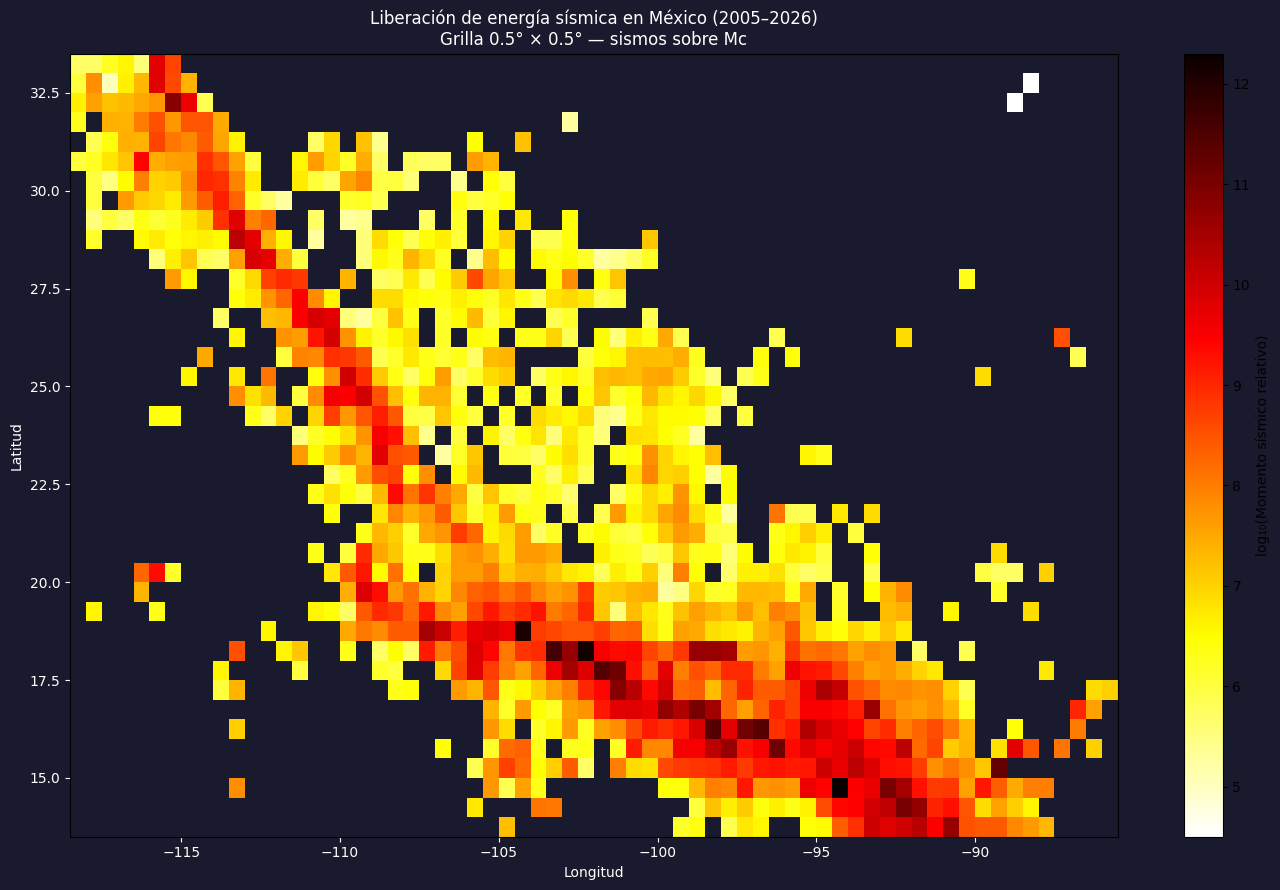

In [4]:
GRID = 0.5
df_mc['lat_bin'] = (df_mc['Latitud']  // GRID) * GRID + GRID / 2
df_mc['lon_bin'] = (df_mc['Longitud'] // GRID) * GRID + GRID / 2

grilla = (
    df_mc.groupby(['lat_bin', 'lon_bin'])
    .agg(momento_total=('momento_sismico', 'sum'), n_sismos=('Magnitud', 'count'))
    .reset_index()
)
grilla['log_momento'] = np.log10(grilla['momento_total'])

pivot = grilla.pivot(index='lat_bin', columns='lon_bin', values='log_momento')

fig, ax = plt.subplots(figsize=(14, 9))
im = ax.pcolormesh(
    pivot.columns, pivot.index, pivot.values,
    cmap='hot_r', shading='auto'
)
plt.colorbar(im, ax=ax, label='log₁₀(Momento sísmico relativo)')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_title('Liberación de energía sísmica en México (2005–2026)\nGrilla 0.5° × 0.5° — sismos sobre Mc')
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
ax.tick_params(colors='white'); ax.xaxis.label.set_color('white'); ax.yaxis.label.set_color('white')
ax.title.set_color('white')
plt.tight_layout()
plt.savefig('heatmap_energia.png', dpi=150, facecolor=fig.get_facecolor())
plt.show()

A través de `Folium`, creamos una visualización más interactiva

In [5]:
# Normalizar log_momento a [0, 1] para el peso del HeatMap
lm_min, lm_max = grilla['log_momento'].min(), grilla['log_momento'].max()
grilla['peso'] = (grilla['log_momento'] - lm_min) / (lm_max - lm_min)

heat_data = grilla[['lat_bin', 'lon_bin', 'peso']].values.tolist()

m = folium.Map(
    location=[23.0, -102.0],
    zoom_start=5,
    tiles='CartoDB dark_matter'
)

HeatMap(
    heat_data,
    radius=12,
    blur=15,
    max_zoom=9,
    gradient={0.2: '#1a237e', 0.4: '#e65100', 0.7: '#ffb300', 1.0: '#ffffff'}
).add_to(m)

folium.LayerControl().add_to(m)
m.save('heatmap_energia.html')
display(HTML(m._repr_html_()))

En un enfoque más temporal, comparamos ocurrencias anual y mensualmente:

C:\Users\Unredeemer\AppData\Local\Temp\ipykernel_19892\3043744273.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_mc['year_month'] = df_mc['datetime_utc'].dt.to_period('M')


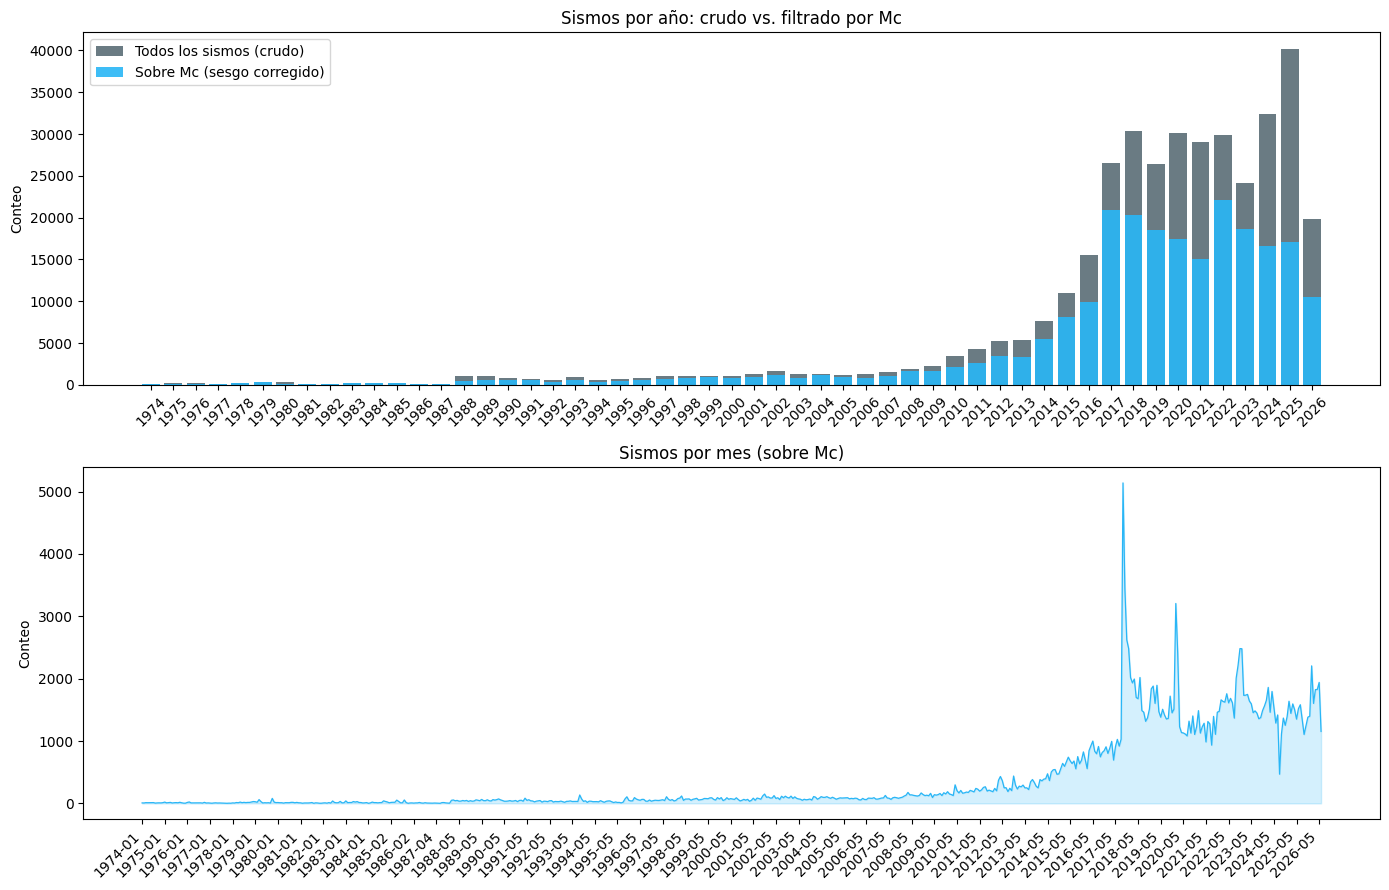

In [6]:
conteo_raw = df.groupby('year').size()
conteo_mc  = df_mc.groupby('year').size()

df_mc['year_month'] = df_mc['datetime_utc'].dt.to_period('M')
conteo_mensual = df_mc.groupby('year_month').size()

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# crudo vs. filtrado por Mc
axes[0].bar(conteo_raw.index, conteo_raw.values, color='#455a64', alpha=0.8, label='Todos los sismos (crudo)')
axes[0].bar(conteo_mc.index,  conteo_mc.values,  color='#29b6f6', alpha=0.9, label='Sobre Mc (sesgo corregido)')
axes[0].set_title('Sismos por año: crudo vs. filtrado por Mc')
axes[0].set_ylabel('Conteo')
axes[0].legend()
axes[0].set_xticks(conteo_raw.index)
axes[0].tick_params(axis='x', rotation=45)

# mensual sobre Mc
x_labels = conteo_mensual.index.astype(str)
axes[1].plot(range(len(x_labels)), conteo_mensual.values, linewidth=0.9, color='#29b6f6')
axes[1].fill_between(range(len(x_labels)), conteo_mensual.values, alpha=0.2, color='#29b6f6')
tick_step = 12  # una etiqueta por año
axes[1].set_xticks(range(0, len(x_labels), tick_step))
axes[1].set_xticklabels(x_labels[::tick_step], rotation=45, ha='right')
axes[1].set_title('Sismos por mes (sobre Mc)')
axes[1].set_ylabel('Conteo')

plt.tight_layout()
plt.savefig('serie_temporal.png', dpi=150)
plt.show()

Pese a no existir correlación como tal, también resulta interesante conocer la distribución de sismos por hora:

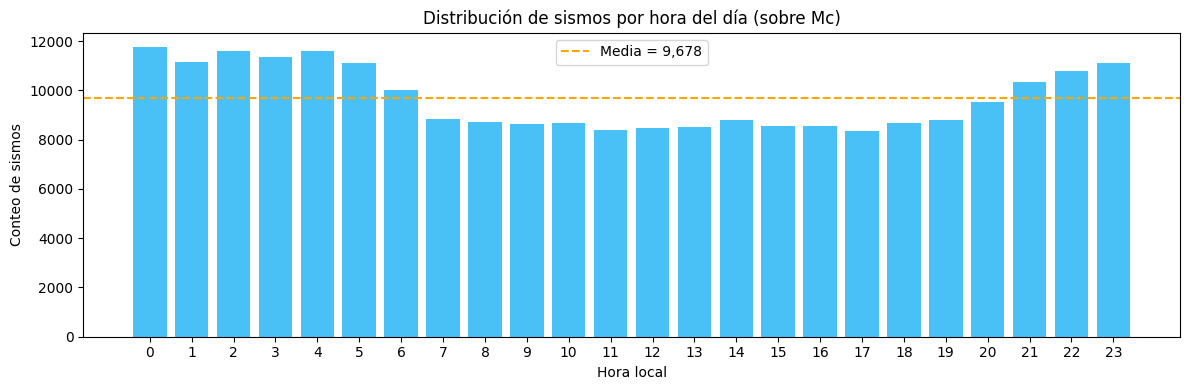

In [7]:
hora_counts = df_mc['hora_local'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(hora_counts.index, hora_counts.values, color='#29b6f6', alpha=0.85)
ax.axhline(hora_counts.mean(), color='orange', linestyle='--', label=f'Media = {hora_counts.mean():,.0f}')
ax.set_xlabel('Hora local')
ax.set_ylabel('Conteo de sismos')
ax.set_title('Distribución de sismos por hora del día (sobre Mc)')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.savefig('distribucion_hora.png', dpi=150)
plt.show()

*Nota*: Dado que se tiene una distribución aproximadamente uniforme, se confirma que la sismicidad no tiene patrón horario.

Visualicemos la profundidad de los sismos en las diversas regiones del país:

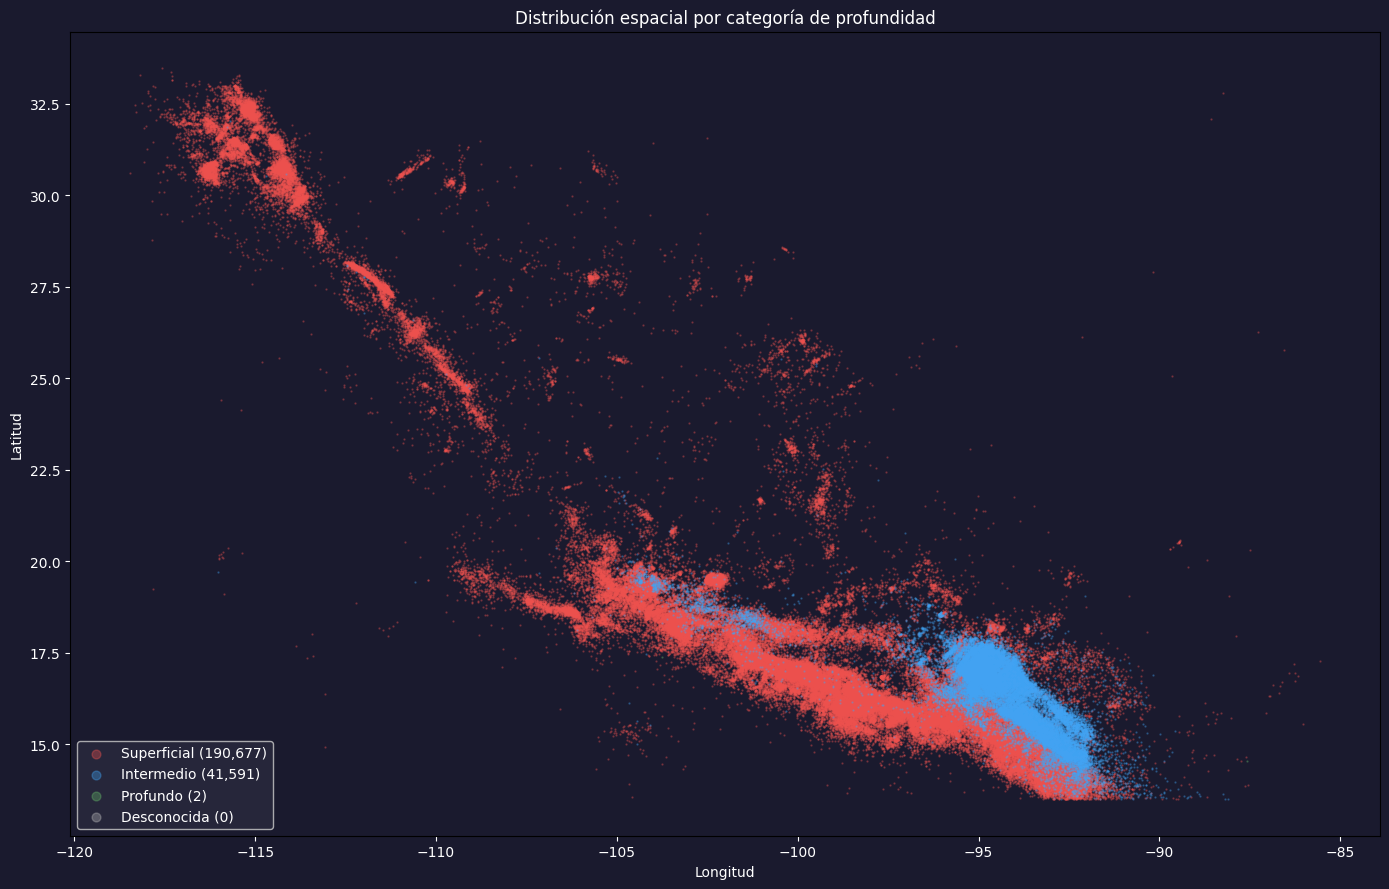

In [ ]:
COLORES_PROF = {
    'Superficial':'#ef5350',
    'Intermedio':'#42a5f5',
    'Profundo':'#66bb6a',
    'Desconocida':'#bdbdbd'
}

fig, ax = plt.subplots(figsize=(14, 9))
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')

for cat, color in COLORES_PROF.items():
    sub = df_mc[df_mc['categoria_prof'] == cat]
    ax.scatter(
        sub['Longitud'], sub['Latitud'],
        c=color, s=0.4, alpha=0.35, label=f'{cat} ({len(sub):,})'
    )

leg = ax.legend(markerscale=10, facecolor='#2a2a3e', labelcolor='white')
ax.set_xlabel('Longitud', color='white')
ax.set_ylabel('Latitud', color='white')
ax.tick_params(colors='white')
ax.set_title('Distribución espacial por categoría de profundidad', color='white')
plt.tight_layout()
plt.savefig('mapa_profundidad.png', dpi=150, facecolor=fig.get_facecolor())
plt.show()

Realizamos un corte en la banda lon -99° a -95°W, donde la placa de Cocos subducta bajo Norteamérica.
El perfil lat vs. profundidad revela la geometría de la losa.

Sismos en la banda (-99.0, -95.0): 73,625


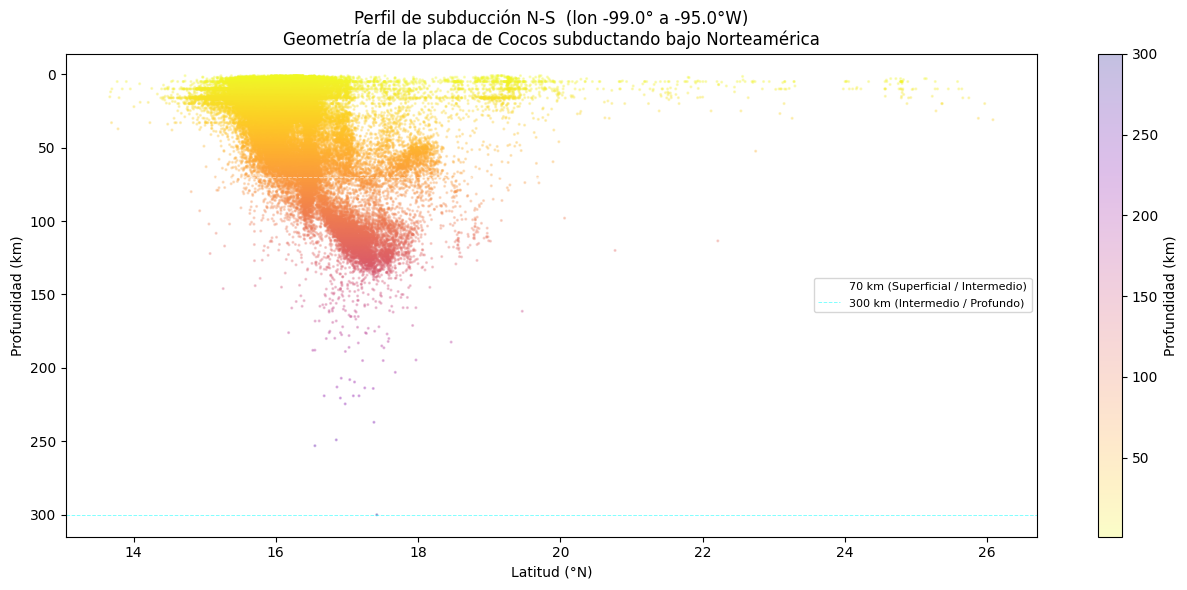

In [9]:
LON_BANDA = (-99.0, -95.0)
perfil = df_mc[
    df_mc['Longitud'].between(*LON_BANDA) &
    df_mc['Profundidad'].notna()
].copy()

print(f'Sismos en la banda {LON_BANDA}: {len(perfil):,}')

fig, ax = plt.subplots(figsize=(13, 6))
sc = ax.scatter(
    perfil['Latitud'], perfil['Profundidad'],
    c=perfil['Profundidad'], cmap='plasma_r',
    s=1.5, alpha=0.25
)
plt.colorbar(sc, ax=ax, label='Profundidad (km)')
ax.invert_yaxis()
ax.set_xlabel('Latitud (°N)')
ax.set_ylabel('Profundidad (km)')
ax.set_title(
    f'Perfil de subducción N-S  (lon {LON_BANDA[0]}° a {LON_BANDA[1]}°W)\n'
    'Geometría de la placa de Cocos subductando bajo Norteamérica'
)
# Líneas de referencia de clasificación
ax.axhline(70,  color='white', linestyle='--', linewidth=0.7, alpha=0.5, label='70 km (Superficial / Intermedio)')
ax.axhline(300, color='cyan',  linestyle='--', linewidth=0.7, alpha=0.5, label='300 km (Intermedio / Profundo)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('perfil_subduccion.png', dpi=150)
plt.show()


Finalmente, para tener un análisis más exhaustivo, realizamos una comparación de profundidad por región disponible:

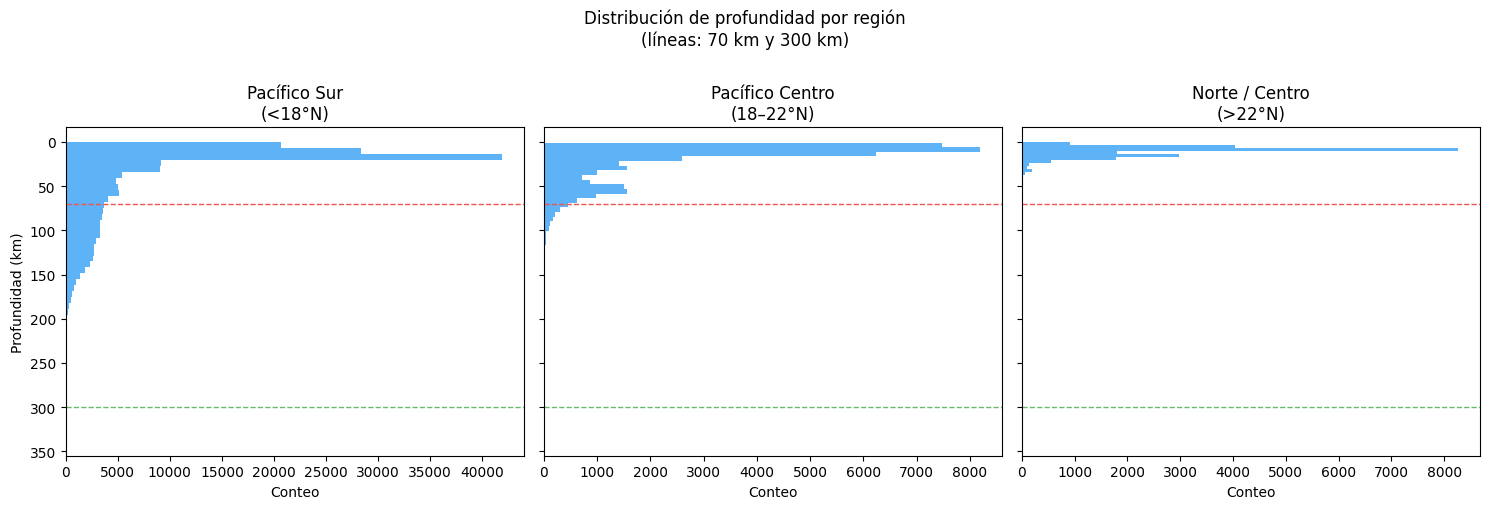

In [10]:
def asignar_region(lat):
    if lat < 18:    
        return 'Pacífico Sur\n(<18°N)'
    elif lat <= 22: 
        return 'Pacífico Centro\n(18–22°N)'
    else:           
        return 'Norte / Centro\n(>22°N)'

df_mc['region'] = df_mc['Latitud'].apply(asignar_region)

regiones = ['Pacífico Sur\n(<18°N)', 'Pacífico Centro\n(18–22°N)', 'Norte / Centro\n(>22°N)']
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, reg in zip(axes, regiones):
    sub = df_mc[df_mc['region'] == reg]['Profundidad'].dropna()
    ax.hist(sub, bins=50, orientation='horizontal', color='#42a5f5', alpha=0.85)
    ax.axhline(70,  color='#ef5350', linestyle='--', linewidth=1)
    ax.axhline(300, color='#66bb6a', linestyle='--', linewidth=1)
    ax.invert_yaxis()
    ax.set_title(reg)
    ax.set_xlabel('Conteo')
    ax.set_ylabel('Profundidad (km)' if ax == axes[0] else '')

fig.suptitle('Distribución de profundidad por región\n(líneas: 70 km y 300 km)', y=1.01)
plt.tight_layout()
plt.savefig('histograma_profundidad.png', dpi=150, bbox_inches='tight')
plt.show()

Para facilitar el despliegue interactivo, creamos pre-agregaciones para `Streamlit`.

In [11]:
# agg_grilla — consumida por el heatmap interactivo del dashboard
agg_grilla = (
    df_mc.groupby(['lat_bin', 'lon_bin', 'year', 'categoria_prof'])
    .agg(
        momento_total=('momento_sismico', 'sum'),
        n_sismos     =('Magnitud', 'count'),
        mag_max      =('Magnitud', 'max')
    )
    .reset_index()
)
agg_grilla.to_parquet('agg_grilla.parquet', index=False)
print(f'agg_grilla.parquet  → {len(agg_grilla):,} filas  ({Path("agg_grilla.parquet").stat().st_size/1e6:.2f} MB)')

# agg_anual — consumida por la serie temporal y filtros de estado/año
agg_anual = (
    df_mc.groupby(['year', 'estado'])
    .agg(
        momento_total=('momento_sismico', 'sum'),
        n_sismos     =('Magnitud', 'count'),
        mag_max      =('Magnitud', 'max')
    )
    .reset_index()
)
agg_anual.to_parquet('agg_anual.parquet', index=False)
print(f'agg_anual.parquet   → {len(agg_anual):,} filas  ({Path("agg_anual.parquet").stat().st_size/1e6:.2f} MB)')

# agg_hora — consumida por el filtro de hora del día
agg_hora = (
    df_mc.groupby('hora_local')
    .agg(n_sismos=('Magnitud', 'count'))
    .reset_index()
)
agg_hora.to_parquet('agg_hora.parquet', index=False)
print(f'agg_hora.parquet    → {len(agg_hora):,} filas  ({Path("agg_hora.parquet").stat().st_size/1e6:.2f} MB)')

agg_grilla.parquet  → 13,948 filas  (0.11 MB)
agg_anual.parquet   → 987 filas  (0.02 MB)
agg_hora.parquet    → 24 filas  (0.00 MB)


Para la creación de filtros posteriores en el dashboard, contamos con la siguiente información:

In [12]:
print(f'Rango de años: {df_mc["year"].min()} – {df_mc["year"].max()}')
print(f'Rango de magnitudes: {df_mc["Magnitud"].min():.1f} – {df_mc["Magnitud"].max():.1f}')
print(f'Categorías de profundidad: {sorted(df_mc["categoria_prof"].unique())}')
print(f'Horas disponibles: 0 – 23 (hora local)')

Rango de años: 1974 – 2026
Rango de magnitudes: 2.2 – 8.2
Categorías de profundidad: ['Intermedio', 'Profundo', 'Superficial']
Horas disponibles: 0 – 23 (hora local)
